In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics.pairwise import cosine_distances
import pickle
import os
import warnings

warnings.filterwarnings('ignore')

print("✅ Étape 1 réussie : Toutes les bibliothèques sont importées.")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Matériel utilisé pour le calcul : {device}")


✅ Étape 1 réussie : Toutes les bibliothèques sont importées.
✅ Matériel utilisé pour le calcul : cpu


In [2]:
print("⬇️ Téléchargement / chargement du dataset LFW...")
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.5, color=True)
print(f"Images chargées : {len(lfw.images)}")

# Aperçu rapide
print("Personnes différentes :", len(lfw.target_names))
print("Exemple de nom :", lfw.target_names[0])


⬇️ Téléchargement / chargement du dataset LFW...
Images chargées : 3023
Personnes différentes : 62
Exemple de nom : Alejandro Toledo


In [3]:
# Initialisation des modèles de visage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")

# Détecteur de visage
mtcnn = MTCNN(
    image_size=160,
    margin=0,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    device=device
)

# Extracteur d'empreinte faciale (embedding)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print("✅ Modèles MTCNN et InceptionResnetV1 initialisés.")


Device utilisé : cpu
✅ Modèles MTCNN et InceptionResnetV1 initialisés.


In [4]:
print("⚙️ Préparation de la base de visages (embeddings)...")

from time import time

def build_or_load_embeddings():
    # Si déjà calculé, on recharge directement
    if os.path.exists("lfw_embeds.npy") and os.path.exists("lfw_meta.pkl"):
        print("📂 Embeddings déjà existants, chargement depuis le disque...")
        embeds = np.load("lfw_embeds.npy")
        with open("lfw_meta.pkl", "rb") as f:
            meta = pickle.load(f)
        print(f"✅ Base chargée : {len(embeds)} visages.")
        return embeds, meta

    print("🧮 Calcul des embeddings en cours (1ère fois seulement)...")
    embeds = []
    names_list = []
    images_list = []

    t0 = time()
    for i, (img, target) in enumerate(zip(lfw.images, lfw.target)):
        # LFW -> numpy float, on reconvertit en uint8 pour PIL
        img_uint8 = (img * 255).astype(np.uint8)
        img_pil = Image.fromarray(img_uint8)

        # 1. Détection du visage
        face = mtcnn(img_pil)
        if face is None:
            continue  # on saute les images où le visage n'est pas bien détecté

        # 2. Embedding
        with torch.no_grad():
            emb = resnet(face.unsqueeze(0).to(device)).cpu().numpy()[0]

        embeds.append(emb)
        names_list.append(lfw.target_names[target])
        images_list.append(img_uint8)

        if (i + 1) % 100 == 0:
            print(f"  → {i+1}/{len(lfw.images)} images traitées")

    embeds = np.array(embeds)
    meta = {
    "names": names_list,
    "images": images_list,
    "source": ["LFW"] * len(names_list)
}

    # Sauvegarde sur disque
    np.save("lfw_embeds.npy", embeds)
    with open("lfw_meta.pkl", "wb") as f:
        pickle.dump(meta, f)

    print(f"✅ Embeddings calculés et sauvegardés ({len(embeds)} visages) en {time()-t0:.1f} s.")
    return embeds, meta

embeds, meta = build_or_load_embeddings()


⚙️ Préparation de la base de visages (embeddings)...
📂 Embeddings déjà existants, chargement depuis le disque...
✅ Base chargée : 2994 visages.


In [5]:
def find_doppelganger(query_path, top_k=3):
    img = Image.open(query_path).convert('RGB')
    face = mtcnn(img)
    if face is None:
        print("⚠️ Aucun visage détecté sur l'image.")
        return None, None

    with torch.no_grad():
        q_emb = resnet(face.unsqueeze(0).to(device)).cpu().numpy()

    dists = cosine_distances(q_emb, embeds).flatten()
    best_idx = np.argsort(dists)[:top_k]

    results = []
    for idx in best_idx:
        results.append({
            "name": meta["names"][idx],
            "score": dists[idx],
            "image": meta["images"][idx]
        })
    return img, results

print("✅ Fonction find_doppelganger prête.")


✅ Fonction find_doppelganger prête.


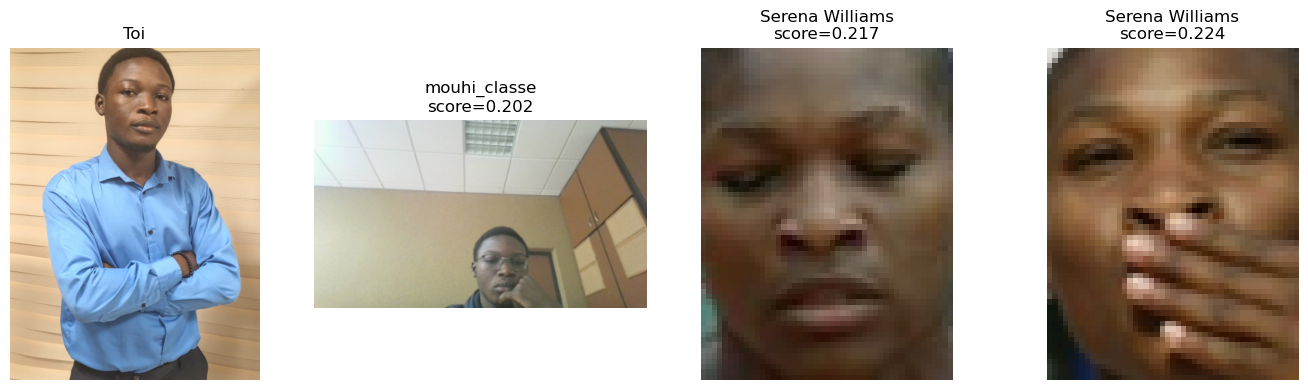

In [6]:
query_image_path = "moi.jpg"  # adapte le nom si besoin

query_img, matches = find_doppelganger(query_image_path, top_k=3)

if query_img is not None:
    fig, axs = plt.subplots(1, 4, figsize=(14,4))
    axs[0].imshow(query_img)
    axs[0].set_title("Toi")
    axs[0].axis("off")

    for i, m in enumerate(matches):
        axs[i+1].imshow(m["image"])
        axs[i+1].set_title(f"{m['name']}\nscore={m['score']:.3f}")
        axs[i+1].axis("off")

    plt.tight_layout()
    plt.show()
